In [49]:
from sklearn.datasets import make_classification
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt


In [14]:
x, y = make_classification(n_samples=5000, n_features=50, random_state=0)
y = y.reshape(-1, 1)

In [15]:
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
print(x.shape) 
print(y.shape)

torch.Size([5000, 50])
torch.Size([5000, 1])


In [38]:
class NueralNet(nn.Module):
    def __init__(self):
        super(NueralNet, self).__init__()
        self.layer1 = nn.Linear(50, 32)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

In [43]:
def sgd_nn(model, x, y, t, epochs):
    loss_fn = nn.BCELoss()
    costs = []
    grad_norms = []
    m = len(y)
    
    for epoch in range(epochs):
        for i in range(m):
            xi = x[i].unsqueeze(0) #use a single data point 
            yi = y[i].unsqueeze(0) #get the label for this point 
            
            model.zero_grad() 
            prediction = model(xi) #forward pass on single point 
            loss = loss_fn(prediction, yi) #compute BCE loss for single point 
            loss.backward() # backward pass 
            
            with torch.no_grad():
                for w in model.parameters():
                    w.data -= t*w.grad #update all parameters with gradient for that point with SGD update for single point 
        
        with torch.no_grad():
            prediction_all = model(x) # run all data through model now  
            epoch_loss = loss_fn(prediction_all, y).item() #BCE Loss for all data 
            costs.append(epoch_loss)
            
        full_grad_norm = 0
        model.zero_grad()
        prediction_all = model(x)
        loss_all = loss_fn(prediction_all, y)
        loss_all.backward() #compute gradient on full data 
        for w in model.parameters():
            if w.grad is not None:
                full_grad_norm += w.grad.norm().item() ** 2 #sum grad norms sqd
        grad_norms.append(full_grad_norm ** 0.5) # take sq root of the sum 
    
    return costs, grad_norms

In [44]:
# SGD on Neural Network
torch.manual_seed(0)
model_sgd = NueralNet()
t = 0.01
epochs = 50

costs_sgd_nn, gradnorms_sgd_nn = sgd_nn(model_sgd, x, y, t, epochs)

print(f"SGD NN: final cost = {costs_sgd_nn[-1]}")
print(f"SGD NN: final grad norm = {gradnorms_sgd_nn[-1]}")

SGD NN: final loss = 0.001140403444878757
SGD NN: final grad norm = 0.0021406120343572996


In [45]:
def saga_nn(model, x, y, t, epochs):
    loss_fn = nn.BCELoss()
    costs = []
    grad_norms = []
    m = len(y)
    
    grad_table = []
    for i in range(m):
        xi = x[i].unsqueeze(0)
        yi = y[i].unsqueeze(0)
        model.zero_grad()
        pred = model(xi)
        loss = loss_fn(pred, yi)
        loss.backward()
        grad_table.append([w.grad.clone() for w in model.parameters()])
    
    avg_grad = [torch.zeros_like(w) for w in model.parameters()]
    for grads in grad_table:
        for k, g in enumerate(grads):
            avg_grad[k] += g / m
    
    for epoch in range(epochs):
        for j in range(m):
            i = torch.randint(0, m, (1,)).item()
            xi = x[i].unsqueeze(0)
            yi = y[i].unsqueeze(0)
            
            model.zero_grad()
            pred = model(xi)
            loss = loss_fn(pred, yi)
            loss.backward()
            grad_new = [w.grad.clone() for w in model.parameters()]
            
            # SAGA update: w = w - t * (grad_new - grad_table[i] + avg_grad)
            with torch.no_grad():
                for k, w in enumerate(model.parameters()):
                    w.data -= t * (grad_new[k] - grad_table[i][k] + avg_grad[k])
            
            # update average gradient
            for k in range(len(avg_grad)):
                avg_grad[k] += (grad_new[k] - grad_table[i][k]) / m
            
            # update gradient table
            grad_table[i] = grad_new
        
        # record cost and grad norm
        with torch.no_grad():
            pred_all = model(x)
            epoch_loss = loss_fn(pred_all, y).item()
            costs.append(epoch_loss)
        
        full_grad_norm = 0
        model.zero_grad()
        pred_all = model(x)
        loss_all = loss_fn(pred_all, y)
        loss_all.backward()
        for w in model.parameters():
            if w.grad is not None:
                full_grad_norm += w.grad.norm().item() ** 2
        grad_norms.append(full_grad_norm ** 0.5)
    
    return costs, grad_norms

In [47]:
torch.manual_seed(0)
model_saga = NueralNet()
t = 0.01
costs_saga_nn, gradnorms_saga_nn = saga_nn(model_saga, x, y, t, epochs=50)
print(f"SAGA NN: final cost = {costs_saga_nn[-1]}")
print(f"SAGA NN: final grad norm = {gradnorms_saga_nn[-1]}")

SAGA NN: final loss = 0.0009270303999073803
SAGA NN: final grad norm = 0.0018668962208081292


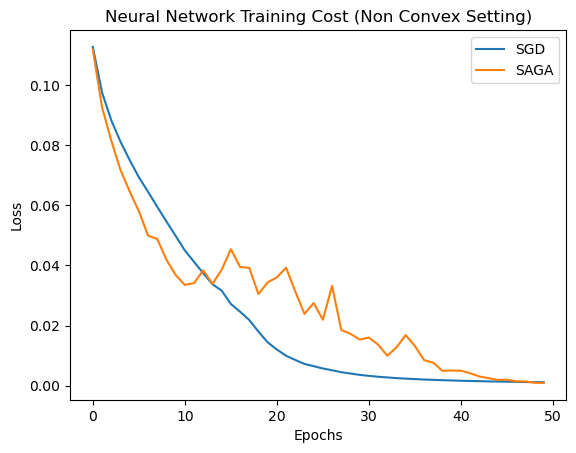

In [50]:
plt.plot(costs_sgd_nn, label='SGD')
plt.plot(costs_saga_nn, label='SAGA')
plt.title('Neural Network Training Cost (Non Convex Setting)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

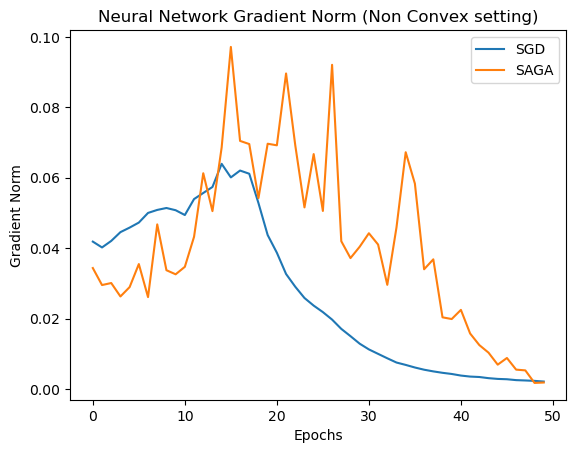

In [54]:
plt.plot(gradnorms_sgd_nn, label='SGD')
plt.plot(gradnorms_saga_nn, label='SAGA')
plt.xlabel('Epochs')
plt.ylabel('Gradient Norm')
plt.title('Neural Network Gradient Norm (Non Convex setting)')
plt.legend()
plt.show()